   age sex  on thyroxine  query on thyroxine  on antithyroid medication  \
0   29   F         False               False                      False   
1   41   F         False               False                      False   
2   36   F         False               False                      False   
3   32   F         False               False                      False   
4   60   F         False               False                      False   

    sick  pregnant  thyroid surgery  I131 treatment  query hypothyroid  ...  \
0  False     False            False           False              False  ...   
1  False     False            False           False              False  ...   
2  False     False            False           False              False  ...   
3  False     False            False           False              False  ...   
4  False     False            False           False              False  ...   

   tumor  hypopituitary  psych  TSH   T3    TT4  T4U  FTI  referral source

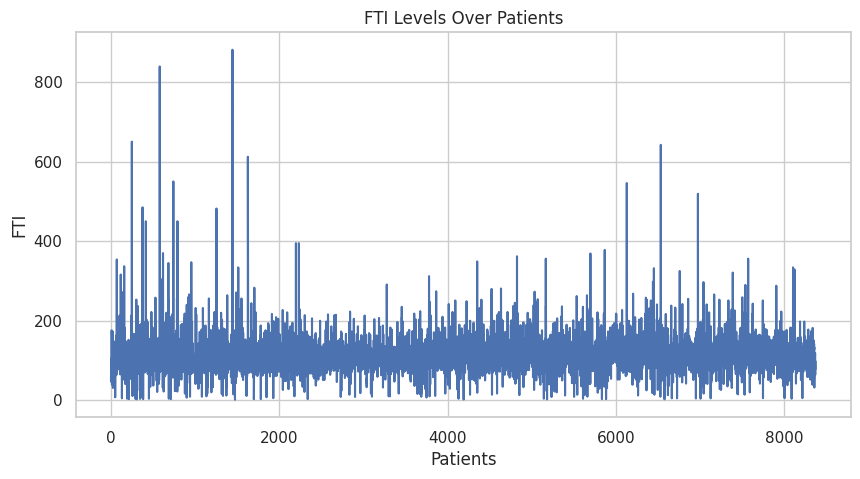

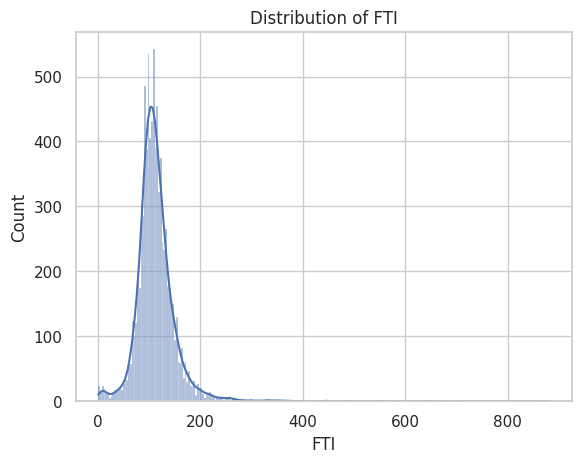

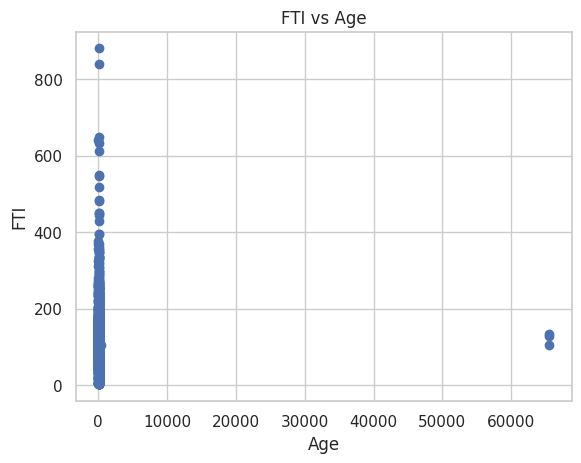

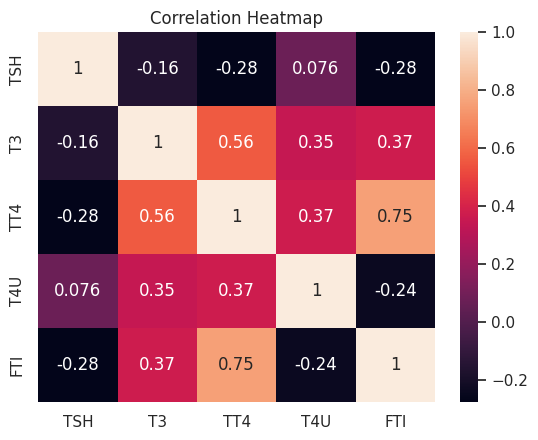

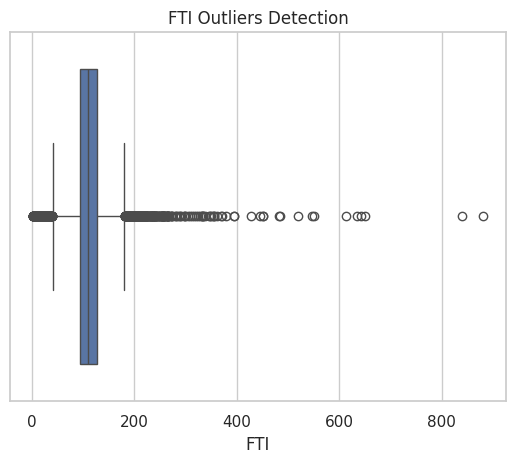

In [2]:
# Thyroid Disease Data Analysis & Visualization


## Importing Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

# Set style
sns.set(style="whitegrid")

## Loading the Dataset
with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("Thyroid-Dataset.csv")
print(df.head())
print(df.info())

## Data Cleaning
df.replace('?', pd.NA, inplace=True)
numeric_cols = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['FTI'])

## FTI Levels Over Patients
plt.figure(figsize=(10,5))
plt.plot(df['FTI'].values)
plt.title("FTI Levels Over Patients")
plt.xlabel("Patients")
plt.ylabel("FTI")
plt.show()

## Distribution of FTI
sns.histplot(df['FTI'], kde=True)
plt.title("Distribution of FTI")
plt.show()

## FTI vs Age
plt.scatter(df['age'], df['FTI'])
plt.xlabel("Age")
plt.ylabel("FTI")
plt.title("FTI vs Age")
plt.show()

## Correlation Between Hormone Levels
corr = df[['TSH','T3','TT4','T4U','FTI']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()


sns.boxplot(x=df['FTI'])
plt.title("FTI Outliers Detection")
plt.show()